# RNN Feature Extraction from Lightcurve Data with K-Means and Logsitc Regression

### Student id: C00313459
### Name: Amisha Das

## 1. Introduction
This notebook uses a vanilla Recurrent Neural Network (RNN) to extract feature vectors from normalized and padded lightcurve data of celestial objects.

Since the dataset lacked labels K-Means was used for clustering and generate pseudo labels and then logistic regression was applied to demonstrate classification capabilties from generated labels.

Dataset [Source](https://arxiv.org/abs/2006.13163)




In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from torch.nn.utils.rnn import pad_sequence


In [3]:
df = pd.read_csv("C:/Users/mishu/Desktop/study/Sem 2/doyle/final submisison/LSTM/nontransient_lightcurves_0.csv")

In [4]:
df = df[['ID', 'MJD', 'Mag']]
df.sort_values(by=['ID', 'MJD'], inplace=True)

In [5]:
# Normalize per lightcurve
scaler = MinMaxScaler()
df['Mag_norm'] = df.groupby('ID')['Mag'].transform(lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten())

In [6]:
# Group into sequences
sequences = []
ids = []
for obj_id, group in df.groupby('ID'):
    mag_seq = group['Mag_norm'].values
    if len(mag_seq) >= 10:
        sequences.append(torch.tensor(mag_seq, dtype=torch.float32))
        ids.append(obj_id)

In [7]:
# Pad to fixed length
max_len = 100
from torch.nn.functional import pad
from torch.nn.utils.rnn import pad_sequence

padded_seqs = pad_sequence(sequences, batch_first=True)
if padded_seqs.shape[1] > max_len:
    X_tensor = padded_seqs[:, :max_len]
else:
    pad_width = max_len - padded_seqs.shape[1]
    X_tensor = pad(padded_seqs, (0, pad_width), value=0)

X_tensor = X_tensor.unsqueeze(-1)  # (batch, seq_len, input_size=1)
X_tensor.shape

torch.Size([7921, 100, 1])

## 2. RNN

In [8]:

class RNNFeatureExtractor(nn.Module):
    def __init__(self, input_size=1, hidden_size=32):
        super(RNNFeatureExtractor, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)

    def forward(self, x):
        out, hidden = self.rnn(x)
        return hidden.squeeze(0)  # (batch, hidden_size)

# Initialize model
model = RNNFeatureExtractor(hidden_size=32)
features = model(X_tensor)  # Extract features
features.shape


torch.Size([7921, 32])

Output: A DataFrame of extracted features for each unique lightcurve (by `ID`).

In [9]:
feature_df = pd.DataFrame(features.detach().numpy())
feature_df['ID'] = ids

In [10]:
feature_df.to_csv("rnn_lightcurve_features.csv", index=False)
feature_df.head()

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,ID
0,0.139571,0.071876,0.070068,0.070476,0.018807,0.249036,-0.038274,0.054965,-0.064802,0.127638,...,0.183166,0.013716,0.063399,0.162642,0.010749,-0.011066,-0.107314,-0.121240,-0.007227,1.001002e+12
1,0.141909,-0.099077,0.123809,0.082821,-0.106872,0.255407,-0.022358,0.067869,-0.190674,0.043169,...,0.097918,0.060832,0.020627,0.227747,0.086358,0.017929,-0.256092,-0.149443,-0.134991,1.001002e+12
2,0.139571,0.071876,0.070068,0.070476,0.018807,0.249036,-0.038274,0.054965,-0.064802,0.127638,...,0.183166,0.013716,0.063399,0.162642,0.010749,-0.011066,-0.107314,-0.121240,-0.007227,1.001002e+12
3,0.089050,-0.030665,0.070503,0.113452,-0.065950,0.242721,0.028597,0.085344,-0.131070,0.074446,...,0.142759,0.045644,0.001499,0.199121,0.050160,0.001072,-0.197829,-0.129709,-0.073130,1.001002e+12
4,0.077245,-0.021200,0.054646,0.134362,-0.066430,0.234068,0.045877,0.087276,-0.117089,0.085417,...,0.150315,0.041552,-0.007475,0.195311,0.048652,0.003491,-0.194898,-0.117415,-0.070024,1.001004e+12


## 3. K-Means Clustering + Logistic Regression

Now clustering the RNN-extracted features using **K-Means**.

Then use the generated cluster labels as pseudo-labels for training a **Logistic Regression** model.


In [11]:
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


cluster the features into 2 classes


In [12]:
kmeans = KMeans(n_clusters=2, random_state=42)
pseudo_labels = kmeans.fit_predict(feature_df.drop(columns=['ID']))

adding pseudo-labels to feature_df

In [13]:
feature_df['pseudo_label'] = pseudo_labels

Splitting data for testing and testing

In [14]:
X = feature_df.drop(columns=['ID', 'pseudo_label'])
y = feature_df['pseudo_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## logistic regression


In [15]:
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [16]:
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.99      1.00       969
           1       0.99      1.00      0.99       616

    accuracy                           0.99      1585
   macro avg       0.99      1.00      0.99      1585
weighted avg       1.00      0.99      0.99      1585



In [17]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
X = feature_df.drop(columns=['ID', 'pseudo_label'])

### PCA

In [19]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X)
pca_df = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])
pca_df['Label'] = feature_df['pseudo_label']

### t-sne plot

In [20]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_components = tsne.fit_transform(X)
tsne_df = pd.DataFrame(tsne_components, columns=['Dim1', 'Dim2'])
tsne_df['Label'] = feature_df['pseudo_label']


### Plot

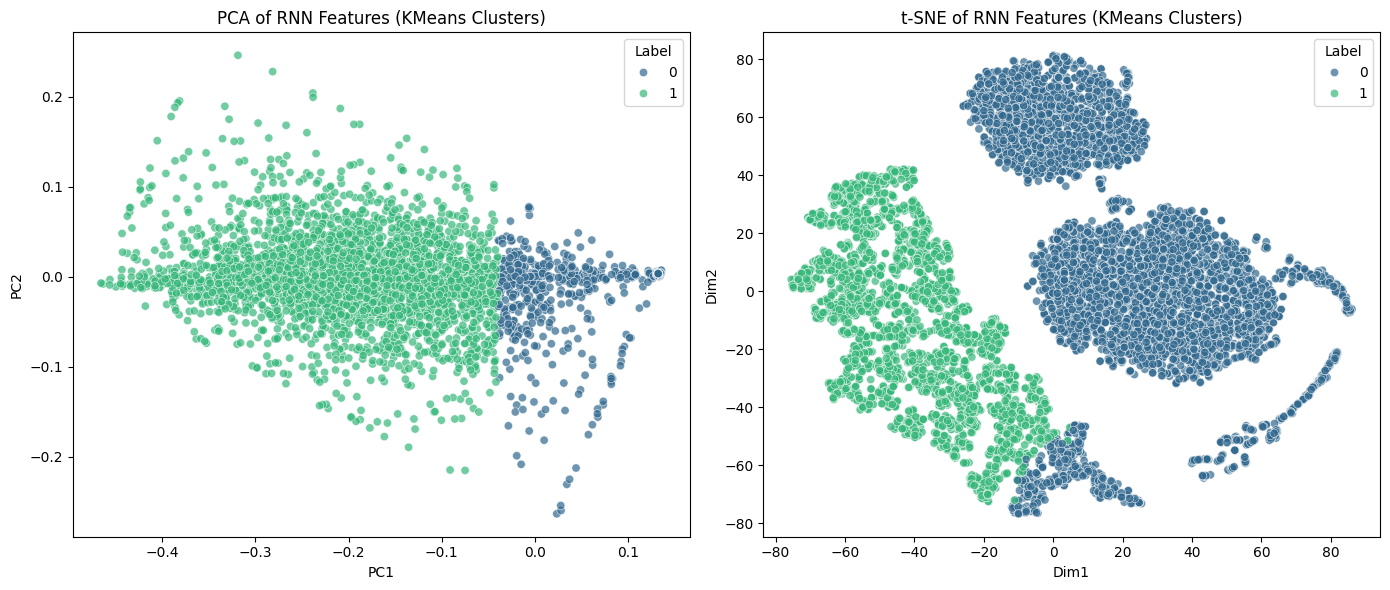

In [21]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Label', palette='viridis', alpha=0.7)
plt.title("PCA of RNN Features (KMeans Clusters)")

plt.subplot(1, 2, 2)
sns.scatterplot(data=tsne_df, x='Dim1', y='Dim2', hue='Label', palette='viridis', alpha=0.7)
plt.title("t-SNE of RNN Features (KMeans Clusters)")

plt.tight_layout()
plt.show()


### 3.1. About the charts:

1. **PCA visualization of RNN-extracted lightcurve features.**
  
   Each point represents a star's lightcurve, and colours indicate clusters assigned by K-Means model. There is a clear distinction between the two clusters as seen by the PCA.

2. **t-SNE visualization of the same RNN feature vectors.**
  
   This projection is non linear (unlike PCA), which shows a well-defined cluster structure. It suggests that the RNN model successfully learned to distinguish patterns in the lightcurve data and was able to cluster it accordinglt.

# 4. Log

In [22]:
import pandas as pd


In [23]:
log = pd.read_csv("RNN_Final_Log_Updated.csv")
pd.set_option('display.max_colwidth', None)
log

,Model,Description,Level of Difficulty,Time Spent (mins),Change From,Changed To,Old Code,New Code
0,RNN,Loaded and normalized lightcurve data by object ID,Medium,30,Raw magnitude data per row,"Grouped, sorted, and min-max scaled sequences",NaN,NaN
1,RNN,Padded lightcurve sequences to uniform length (100 timesteps),Medium,20,Variable-length sequences,Uniform 2D tensor input for RNN,NaN,NaN
2,RNN,Implemented vanilla RNN to extract 32-dimensional feature vectors,Hard,60-80,NaN,Custom PyTorch nn.RNN model with feature output,NaN,NaN
3,K-Means,Clustered RNN features into 2 groups as pseudo-labels,Medium,20,Unlabeled feature set,Cluster-labeled dataset for downstream use,NaN,NaN
4,Logistic Regression,Trained and evaluated classifier using pseudo-labels from K-Means,Medium,30,No label-based evaluation,~1.00 F1 score on KMeans-based labels,NaN,NaN
5,RNN + Clustering,Visualized PCA and t-SNE plots of clustered features,Easy,40,No visual understanding of feature separability,2D projections showing distinct cluster boundaries,NaN,NaN
6,ALL,"End-to-end pipeline: data prep, RNN, clustering, classification, visualization",Hard,60,No structured workflow,"Clean, reproducible, modular notebook with outputs",NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,total,200,NaN,NaN,NaN,NaN


# 5. Conclusion:

In this notebook we performed the following:
1. Processed and normalised lightcurve data to extract meaningful feature vectors.
2. These features were clustered using K-Means and labels were generated 
3. Then logistic regression was used to achieve strong classification (99%)

### Appendices, Acknowledgments and References

- [Time Series Forecasting With RNN(LSTM)| Complete Python Tutorial|](https://www.youtube.com/watch?v=S8tpSG6Q2H0)
- [Comparison of Classification, Regression & RNN ](https://www.kaggle.com/code/skloveyyp/comparison-of-classification-regression-rnn)
- ChatGPT for code debugging
- [A recurrent neural network for classification of unevenly sampled data](https://arxiv.org/pdf/1711.10609)
- [How to apply k-means to 4D Tensor](https://discuss.ai.google.dev/t/how-to-apply-k-means-clustering-to-4d-tensor/32397)